# Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST


**В качестве интерфейса для работы с моделями используйте [Gradio](https://colab.research.google.com/drive/18EM8mrpURStkmbxWjZybWbWh23Si5b4A#scrollTo=-uu_VR8H2K4h)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

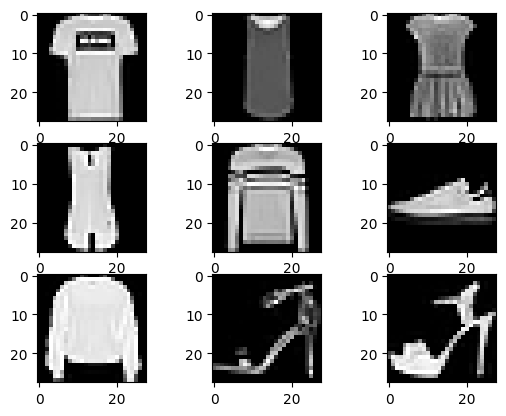

In [ ]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Компиляция модели
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Вывод информации о модели
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [ ]:
# Изменение размерности данных и нормализация
trainX = trainX.reshape((trainX.shape[0], 28, 28, 1)).astype('float32') / 255.0
testX = testX.reshape((testX.shape[0], 28, 28, 1)).astype('float32') / 255.0

# Обучение модели
history = model.fit(trainX, trainy, epochs=10, batch_size=32, validation_data=(testX, testy))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.7800 - loss: 0.6055 - val_accuracy: 0.8730 - val_loss: 0.3535
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.8884 - loss: 0.3080 - val_accuracy: 0.8859 - val_loss: 0.3134
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9058 - loss: 0.2576 - val_accuracy: 0.8951 - val_loss: 0.2810
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9183 - loss: 0.2203 - val_accuracy: 0.8952 - val_loss: 0.2792
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9277 - loss: 0.1927 - val_accuracy: 0.9057 - val_loss: 0.2619
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9340 - loss: 0.1701 - val_accuracy: 0.9075 - val_loss: 0.2569
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9430 - loss: 0.1510 - val_accuracy: 0.9107 - val_loss: 0.2643
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9498 -

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

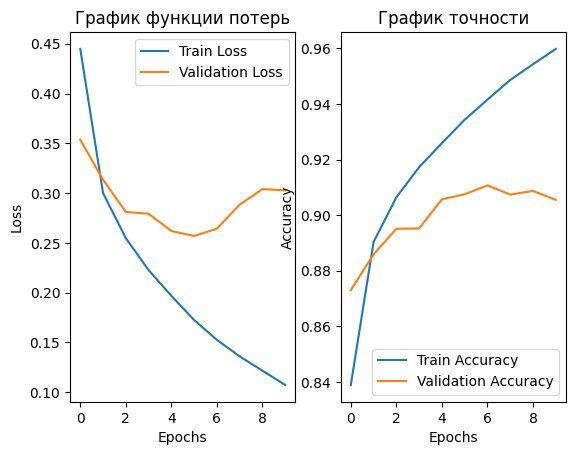

In [ ]:
# График функции потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('График функции потерь')

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('График точности')

plt.show()

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


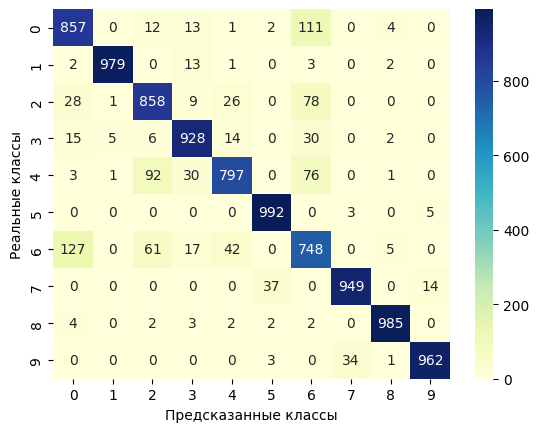

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Получаем предсказания модели (вероятности для каждого класса)
Y_pred = model.predict(testX, batch_size=10)

# Преобразуем вероятности в метки классов
Y_pred_labels = Y_pred.argmax(axis=1)

Y_val_labels = testy

# Строим матрицу ошибок
conf_mat = confusion_matrix(Y_val_labels, Y_pred_labels)

# Визуализация
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu")
plt.xlabel("Предсказанные классы")
plt.ylabel("Реальные классы")
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
drive_path = 'drive/MyDrive/neural_networks/3lab/'

Mounted at /content/drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Предсказанный класс: Bag (100.00%)


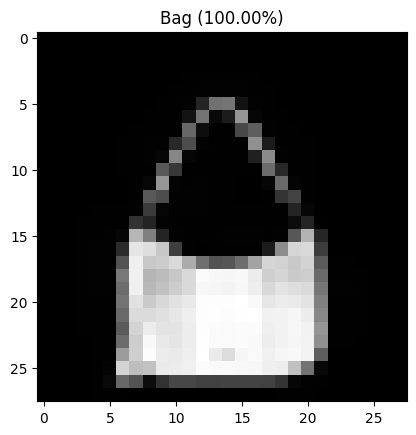

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Предсказанный класс: Dress (100.00%)


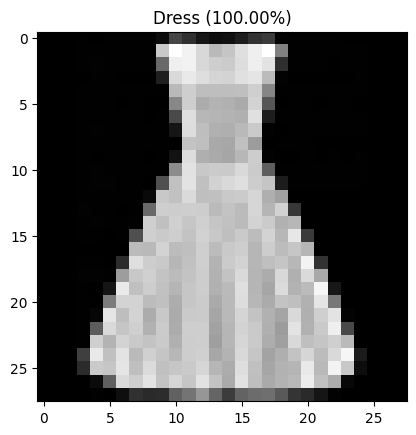

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Предсказанный класс: Trouser (100.00%)


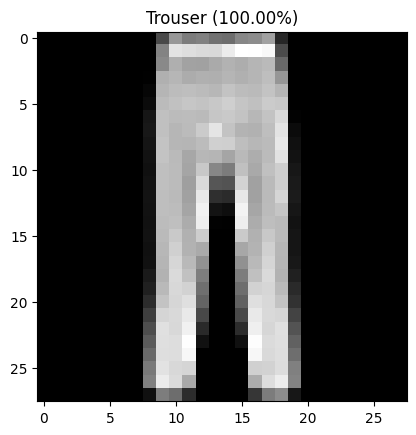

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Предсказанный класс: Sneaker (99.93%)


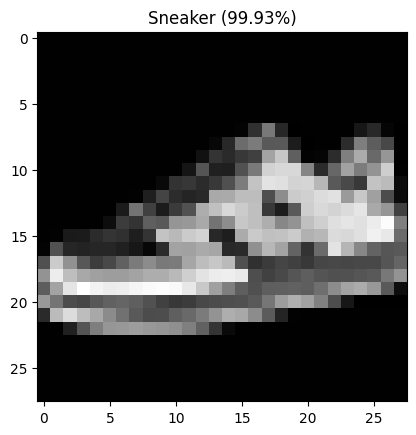

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Предсказанный класс: T-shirt/top (79.96%)


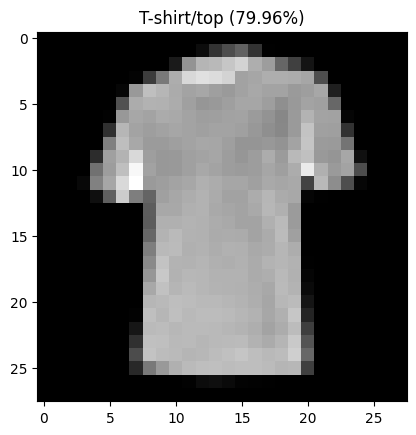

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

class_labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Загружаем в градациях серого

    # Проверяем, нужно ли инвертировать цвета
    if np.mean(image) > 127:  # Если изображение слишком светлое → инвертируем
        image = 255 - image

    # Улучшаем контраст (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)

    # Изменяем размер (с сохранением четкости)
    image = cv2.resize(image, (28, 28), interpolation=cv2.INTER_AREA)

    # Нормализация (0-1)
    image = image.astype('float32') / 255.0

    # Преобразуем в нужную форму (1, 28, 28, 1)
    return image.reshape(1, 28, 28, 1)

def predict_custom_image(image_path):
    image = preprocess_image(image_path)

    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print(f"Предсказанный класс: {class_labels[predicted_class]} ({confidence:.2f}%)")

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"{class_labels[predicted_class]} ({confidence:.2f}%)")
    plt.show()

image_paths = ["bag.jpg", "dress.jpg", "trousers.jpg", "sneaker.jpg", "tshirt.jpg"]
for img_path in image_paths:
    img_path = drive_path + 'val/' + img_path
    predict_custom_image(img_path)

# Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

data_dir = '/content/drive/MyDrive/neural_networks/2lab_dataset'
classes = ['chicken', 'slonyara', 'horse']
img_size = (128, 128)

X = []
y = []

for class_idx, class_name in enumerate(classes):
    class_dir = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_dir):
        # Пропускаем скрытые файлы и не-JPG файлы
        if img_name.startswith('.') or not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(class_dir, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize(img_size)
            X.append(np.array(img))
            y.append(class_idx)
        except Exception as e:
            print(f"Ошибка при обработке {img_path}: {e}")
            continue

X = np.array(X) / 255.0
y = to_categorical(np.array(y), num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Ошибка при обработке /content/drive/MyDrive/neural_networks/2lab_dataset/chicken/440.jpeg: cannot identify image file '/content/drive/MyDrive/neural_networks/2lab_dataset/chicken/440.jpeg'


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.3742 - loss: 1.1235 - val_accuracy: 0.4967 - val_loss: 0.9632
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.5239 - loss: 0.9958 - val_accuracy: 0.6550 - val_loss: 0.8278
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5901 - loss: 0.8909 - val_accuracy: 0.6500 - val_loss: 0.7196
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.6394 - loss: 0.8073 - val_accuracy: 0.7417 - val_loss: 0.6301
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.6709 - loss: 0.7390 - val_accuracy: 0.6483 - val_loss: 0.7401
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7284 - loss: 0.6872 - val_accuracy: 0.7100 - val_loss: 0.5989
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7382 - loss: 0.6217 - val_accuracy: 0.8533 - val_loss: 0.4201
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7541 - loss: 0.6288 - val_accuracy: 0.8317 - val

In [ ]:
model.save(drive_path + 'animal.keras')

## 2.2.   Ознакомьтесь с современными архитектурами сверточных нейронных сетей: [см. ссылку](https://medium.com/aiguys/how-cnn-architectures-evolved-c53d3819fef8). На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
##ALEXNET
alexnet_model = Sequential([
    # 1-й сверточный блок
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=2),

    # 2-й сверточный блок
    Conv2D(256, (5, 5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3, 3), strides=2),

    # 3-й сверточный блок
    Conv2D(384, (3, 3), padding='same', activation='relu'),

    # 4-й сверточный блок
    Conv2D(384, (3, 3), padding='same', activation='relu'),

    # 5-й сверточный блок
    Conv2D(256, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((3, 3), strides=2),

    # Полносвязные слои
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

# Создаем модель
alexnet_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

alexnet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 30, 30, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 6, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,740,611 (94.38 MB)

 Trainable params: 24,739,907 (94.38 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

history = alexnet_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.4048 - loss: 1.1804 - val_accuracy: 0.3267 - val_loss: 1.1048
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.5703 - loss: 0.9217 - val_accuracy: 0.3267 - val_loss: 1.1768
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.6454 - loss: 0.7743 - val_accuracy: 0.3267 - val_loss: 1.4710
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.7160 - loss: 0.6856 - val_accuracy: 0.3983 - val_loss: 1.1734
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7370 - loss: 0.6662 - val_accuracy: 0.5800 - val_loss: 0.8825
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7747 - loss: 0.5752 - val_accuracy: 0.6400 - val_loss: 0.7816
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7655 - loss: 0.5661 - val_accuracy: 0.7183 - val_loss: 0.6599
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.7709 - loss: 0.5491 - val_accuracy: 0.8383 - v

## 2.3. Сохраните полученные модели

In [ ]:
alexnet_model.save(drive_path + 'alextnet_animals.keras')

## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
from tensorflow.keras.models import load_model
lab2_model = load_model("drive/MyDrive/neural_networks/best_model_10.keras")


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы


Результаты классификации:
- Моя сверточная модель: horse (96.92%)
- AlexNet: slon (84.63%)
- 2lab: chicken (87.80%)


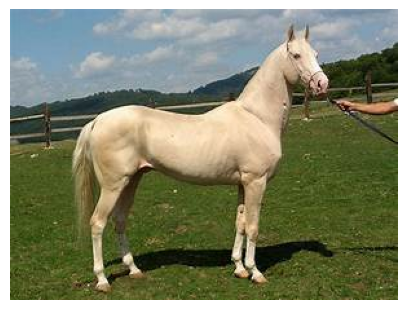


Результаты классификации:
- Моя сверточная модель: horse (95.05%)
- AlexNet: slon (54.70%)
- 2lab: horse (45.29%)


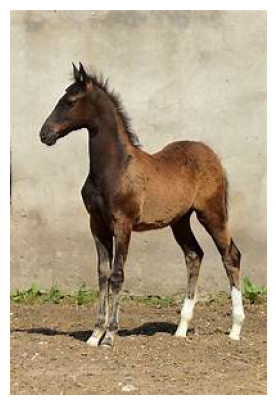


Результаты классификации:
- Моя сверточная модель: horse (98.61%)
- AlexNet: horse (87.41%)
- 2lab: horse (67.05%)


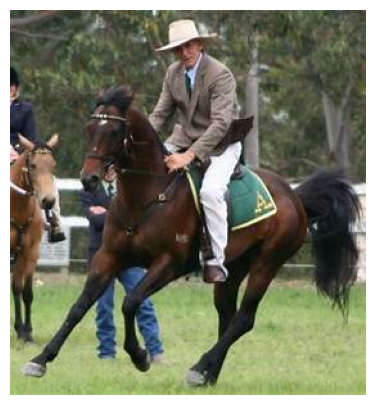


Результаты классификации:
- Моя сверточная модель: slon (59.09%)
- AlexNet: slon (98.65%)
- 2lab: chicken (86.69%)


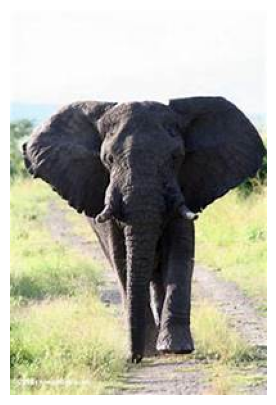


Результаты классификации:
- Моя сверточная модель: horse (59.16%)
- AlexNet: slon (94.54%)
- 2lab: chicken (66.52%)


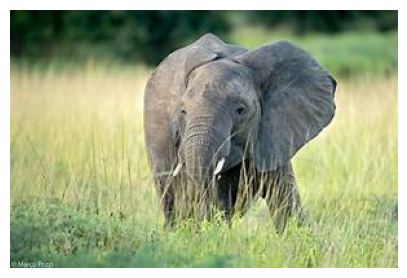


Результаты классификации:
- Моя сверточная модель: chicken (100.00%)
- AlexNet: horse (62.48%)
- 2lab: chicken (83.41%)


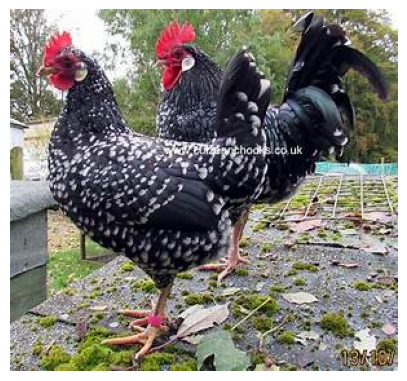


Результаты классификации:
- Моя сверточная модель: slon (99.17%)
- AlexNet: slon (99.99%)
- 2lab: chicken (59.53%)


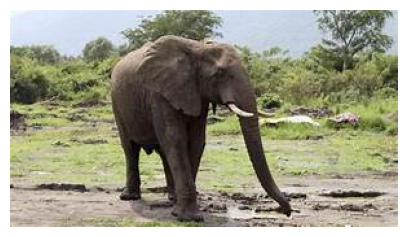


Результаты классификации:
- Моя сверточная модель: chicken (99.96%)
- AlexNet: slon (45.10%)
- 2lab: chicken (92.15%)


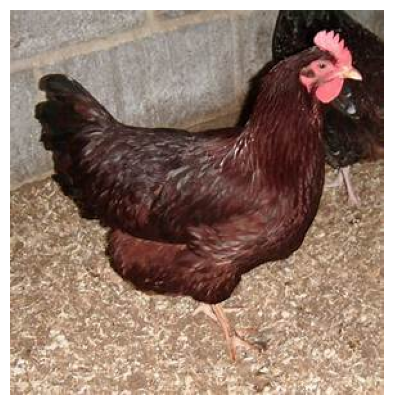


Результаты классификации:
- Моя сверточная модель: chicken (97.12%)
- AlexNet: slon (67.11%)
- 2lab: horse (58.75%)


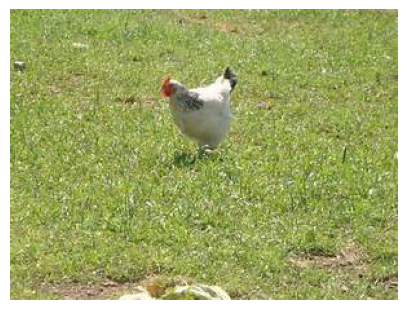


Результаты классификации:
- Моя сверточная модель: slon (57.42%)
- AlexNet: slon (75.24%)
- 2lab: horse (39.41%)


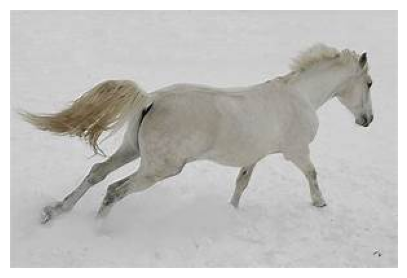


Результаты классификации:
- Моя сверточная модель: horse (97.37%)
- AlexNet: slon (95.54%)
- 2lab: horse (71.97%)


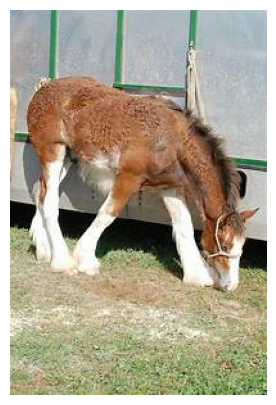


Результаты классификации:
- Моя сверточная модель: slon (64.78%)
- AlexNet: slon (82.65%)
- 2lab: horse (56.88%)


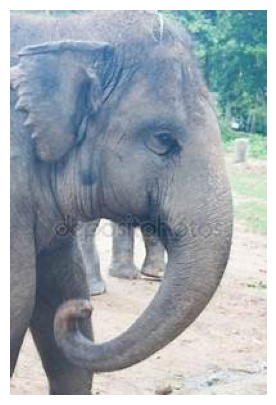


Результаты классификации:
- Моя сверточная модель: chicken (98.90%)
- AlexNet: slon (43.95%)
- 2lab: horse (71.42%)


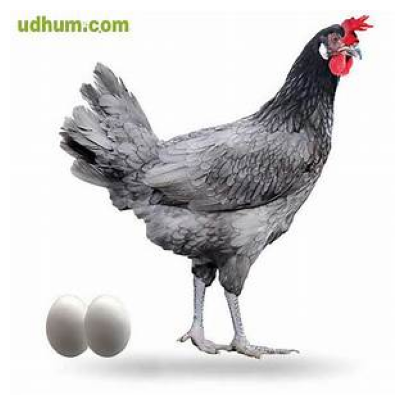


Результаты классификации:
- Моя сверточная модель: chicken (99.70%)
- AlexNet: slon (89.98%)
- 2lab: horse (42.13%)


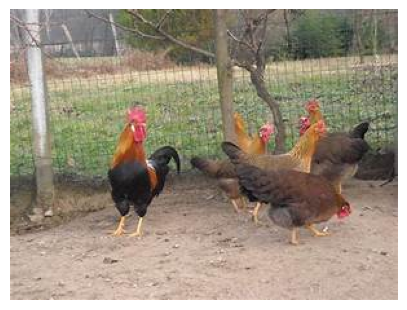


Результаты классификации:
- Моя сверточная модель: slon (79.94%)
- AlexNet: slon (98.64%)
- 2lab: chicken (94.42%)


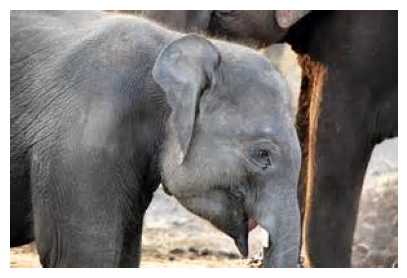

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
import cv2

models = {
    "Моя сверточная модель": load_model(drive_path + 'animal.keras'),
    "AlexNet": load_model(drive_path + 'alextnet_animals.keras'),
    "2lab": load_model('drive/MyDrive/neural_networks/best_model_10.keras')
}

def predict_with_all_models(img_path, models):
    """Предсказывает класс для изображения используя все модели"""
    try:
        # Загрузка изображения
        img = image.load_img(img_path)
        img_array = image.img_to_array(img) / 255.0

        # Классы
        classes = {0: 'chicken', 1: 'slon', 2: 'horse'}

        # Получаем предсказания
        results = []
        for model_name, model in models.items():
            try:
                if model_name == "2lab":
                    img_processed = cv2.resize(img_array, (64, 64)).reshape(1, -1)
                else:
                    img_processed = cv2.resize(img_array, (128, 128))
                    img_processed = np.expand_dims(img_processed, axis=0)

                pred = model.predict(img_processed, verbose=0)
                class_idx = np.argmax(pred[0])
                confidence = np.max(pred[0])
                results.append(f"{model_name}: {classes[class_idx]} ({confidence:.2%})")

            except Exception as e:
                print(f"Ошибка в модели {model_name}: {str(e)}")
                continue

        print("\nРезультаты классификации:")
        for res in results:
            print(f"- {res}")

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        return results

    except Exception as e:
        print(f"Ошибка обработки {img_path}: {str(e)}")
        return None

# Получаем все изображения
image_extensions = ('.jpg', '.jpeg', '.JPG', '.JPEG')
image_path = os.path.join(drive_path, "15_test")
image_files = [os.path.join(image_path, f) for f in os.listdir(image_path)
              if f.lower().endswith(image_extensions) and os.path.isfile(os.path.join(image_path, f))]

# Обрабатываем все изображения
for img_path in sorted(image_files):
    predict_with_all_models(img_path, models)

Свёрточная нейронная сеть показала более высокую точность по сравнению с другими моделями

# Задание №3*. Использование глубокой сверточной нейронной сети для восстановления изображения

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [ ]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

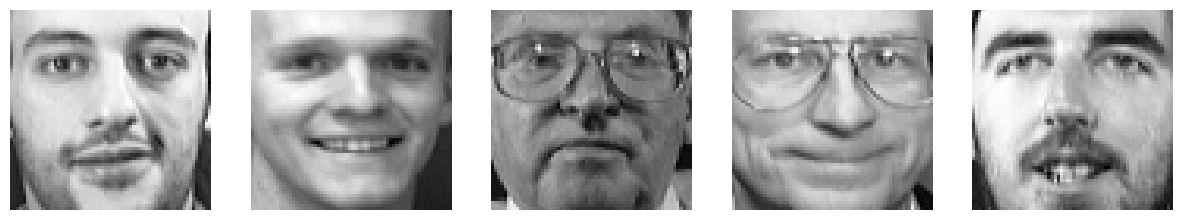

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

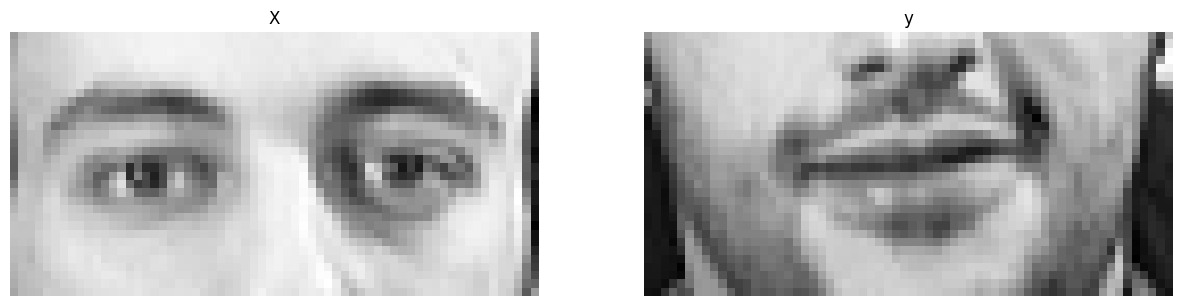

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D,Flatten, Dense, MaxPooling2D

model = Sequential([
    Conv2D(128, (3,3), padding='same', activation='relu', input_shape=(32, 64, 1)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Flatten(),
    Dense(4096, activation='relu'),
    Dense(32*64,  activation='sigmoid')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 64, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2048)           │     8,390,656 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,024,256 (160.31 MB)

 Trainable params: 42,024,256 (160.31 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [ ]:
y_train = y_train.reshape(len(y_train), 2048)
y_test = y_test.reshape(len(y_test), 2048)

print(y_train.shape)
print(y_test.shape)

(320, 2048)
(80, 2048)


## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [ ]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=0.001)

model.compile(optimizer=opt,
             loss='mse',
             metrics=['mse'])

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_test, y_test))

model.evaluate(X_test, y_test)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0237 - mse: 0.0237 - val_loss: 0.0204 - val_mse: 0.0204
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0209 - mse: 0.0209 - val_loss: 0.0201 - val_mse: 0.0201
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 0.0206 - mse: 0.0206 - val_loss: 0.0193 - val_mse: 0.0193
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0191 - mse: 0.0191 - val_loss: 0.0185 - val_mse: 0.0185
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - loss: 0.0184 - mse: 0.0184 - val_loss: 0.0169 - val_mse: 0.0169
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0174 - mse: 0.0174


[0.01685972511768341, 0.01685972511768341]

## 3.5. Сделайте предсказания на тестовых данных

In [ ]:
preds = model.predict(X_test, batch_size=16)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step


## 3.6. Посчитайте метрику качества на тестовых данных

In [ ]:
# Ваш код здесь

from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test_n)

0.10307202488183975

## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [ ]:
preds = preds.reshape(80, 32, 64)
y_test = y_test.reshape(80, 32, 64)

preds.shape

(80, 32, 64)

Отрисуйте все предсказания.

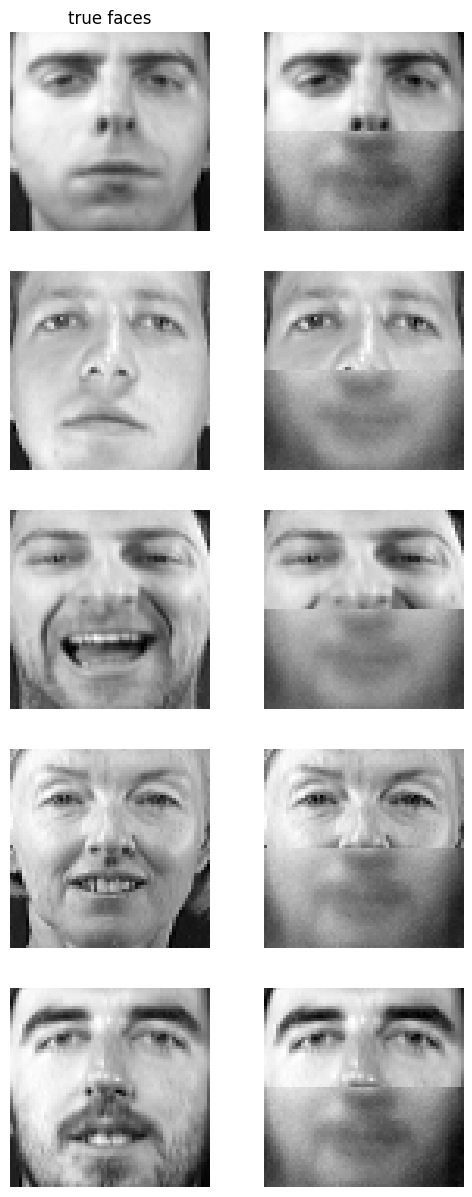

In [ ]:
import numpy as np
n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], preds[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )